NLP Project5


In [6]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud

# Download NLTK data (Run once)
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
df = pd.read_csv(
    "/content/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None,
    quotechar='"',
    doublequote=True,
    engine='python',
    on_bad_lines='skip'
)

In [8]:
# Assign column names
df.columns = [
    "Sentiment",
    "ID",
    "Date",
    "Query",
    "User",
    "Tweet"
]

print(df.head())

df = df.sample(10000, random_state=42)

print("Dataset Shape:", df.shape)

   Sentiment          ID                          Date     Query  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              User                                              Tweet  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  
Dataset Shape: (10000, 6)


In [9]:
# Convert Labels


df["Original_Sentiment"] = df["Sentiment"].replace({
    0: "Negative",
    4: "Positive"
})

In [16]:
# Text Cleaning


stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

print(df[["Tweet","Clean_Tweet"]].head())

                                                    Tweet  \
541200             @chrishasboobs AHHH I HOPE YOUR OK!!!    
750     @misstoriblack cool , i have no tweet apps  fo...   
766711  @TiannaChaos i know  just family drama. its la...   
285055  School email won't open  and I have geography ...   
705995                             upper airways problem    

                                              Clean_Tweet  
541200                                       ahhh hope ok  
750                                  cool tweet apps razr  
766711  know family drama lamehey next time u hang kim...  
285055  school email wont open geography stuff revise ...  
705995                               upper airway problem  


In [17]:
# ---------------------------------------------------
# Sentiment Analysis using TextBlob
# ---------------------------------------------------

def predict_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df["Predicted_Sentiment"] = df["Clean_Tweet"].apply(predict_sentiment)

print(df["Predicted_Sentiment"].value_counts())

Predicted_Sentiment
Positive    4261
Neutral     3740
Negative    1999
Name: count, dtype: int64


In [18]:

# Topic Modeling (Trending Topics)


vectorizer = CountVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(df["Clean_Tweet"])

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(X)

words = vectorizer.get_feature_names_out()

print("\nTrending Topics\n")

for i, topic in enumerate(lda.components_):

    print("Topic", i+1)

    top_words = [words[index] for index in topic.argsort()[-10:]]

    print(top_words)

    print()


Trending Topics

Topic 1
['work', 'thats', 'looking', 'getting', 'game', 'yes', 'fun', 'way', 'wait', 'going']

Topic 2
['hope', 'week', 'look', 'work', 'like', 'got', 'new', 'oh', 'really', 'sad']

Topic 3
['feel', 'school', 'morning', 'wish', 'friend', 'thanks', 'today', 'need', 'good', 'day']

Topic 4
['hate', 'time', 'good', 'miss', 'like', 'think', 'want', 'love', 'know', 'dont']

Topic 5
['nice', 'sorry', 'like', 'sleep', 'good', 'great', 'day', 'night', 'lol', 'im']



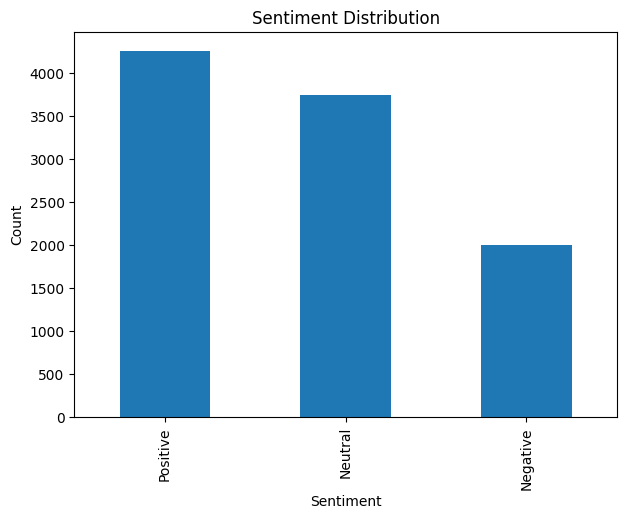

In [19]:
# Bar Chart

plt.figure(figsize=(7,5))

df["Predicted_Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

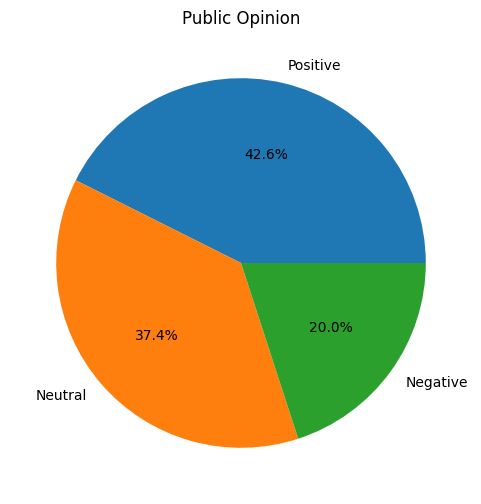

In [20]:

# Pie Chart


plt.figure(figsize=(6,6))

df["Predicted_Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Public Opinion")

plt.show()

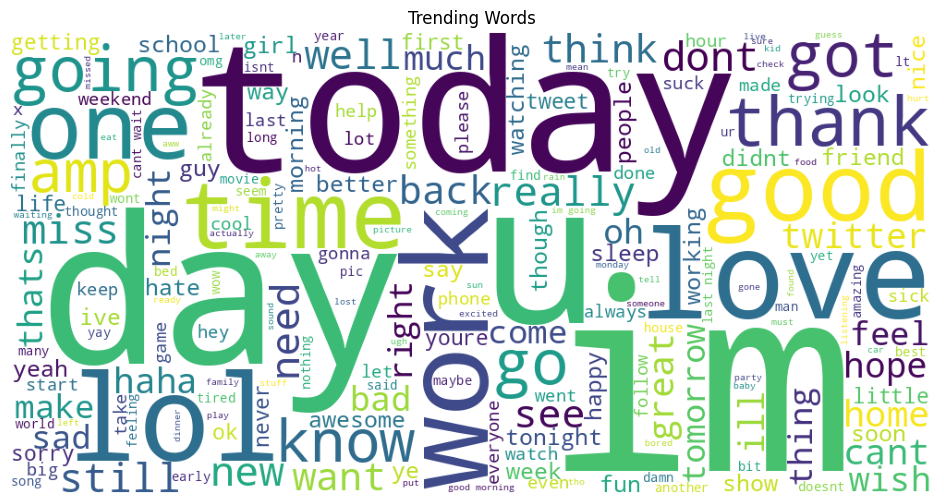

In [21]:

# Word Cloud


text = " ".join(df["Clean_Tweet"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Trending Words")

plt.show()

In [23]:
# Save Output


df.to_csv("Sentiment140_Result.csv", index=False)

print("Analysis Completed Successfully")

Analysis Completed Successfully
